# Nijmegen Floods - Non-Parametric Bayesian Networks

### Importing necessary packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from Functions import *
from py_banshee.rankcorr import bn_rankcorr
from py_banshee.copula_test import cvm_statistic
from py_banshee.sample_bn import generate_samples
from py_banshee.bn_plot import bn_visualize
from py_banshee.d_cal import test_distance
from py_banshee.prediction import inference

## Environmental Variables

The following environmental variables are extracted and used for the NPBN analysis:
- $Q$: River discharge of the river Waal
- $T$: Temperature in the alps (Grimsel Hospiz station - Switserland)
- $P$: Precipitation in Düsseldorf
- $GW$: Groundwater levels near Nijmegen (Wijchen)

All data is imported from different data file-types, and resampled to daily mean values.

### River Discharge

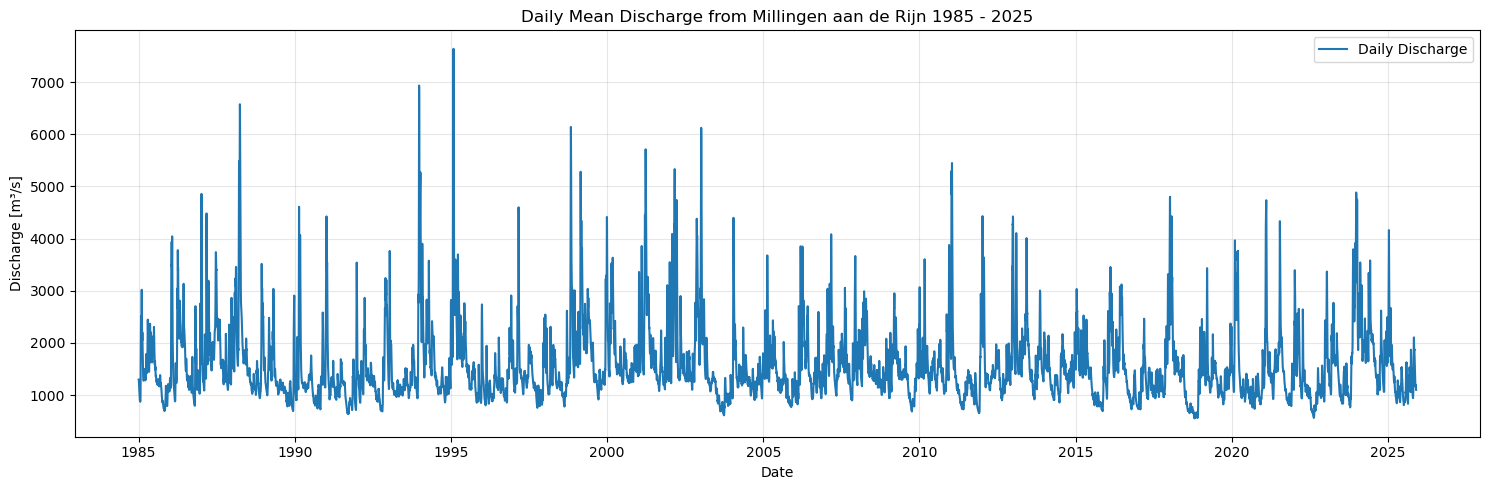

In [2]:
discharge_files = ['data/Mill1.csv', 'data/Mill2.csv', 'data/Mill3.csv', 'data/Mill4.csv']

df_discharge = []

for file_name in discharge_files:
    df = pd.read_csv(file_name, sep=';')

    df["datum"] = pd.to_datetime(df["datum"], dayfirst=True)                        # convert to datetime     
    df["waarde"] = pd.to_numeric(df["waarde"].astype(str).str.replace(",", "."))    # convert to numeric
    df.loc[df["waarde"] > 1e5, "waarde"] = np.nan                                   # remove outliers
    df = df.dropna(subset=["datum", "waarde"])                                      # drop rows with NaN

    # Resample to daily mean
    daily_part = df.groupby("datum")["waarde"].mean()
    df_discharge.append(daily_part)

df_discharge = pd.concat(df_discharge).sort_index()


plt.figure(figsize=(15, 5))
plt.plot(df_discharge.index, df_discharge.values, label = "Daily Discharge")
plt.xlabel("Date")
plt.ylabel("Discharge [m³/s]")
plt.title("Daily Mean Discharge from Millingen aan de Rijn 1985 - 2025")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()


### Temperature Alps

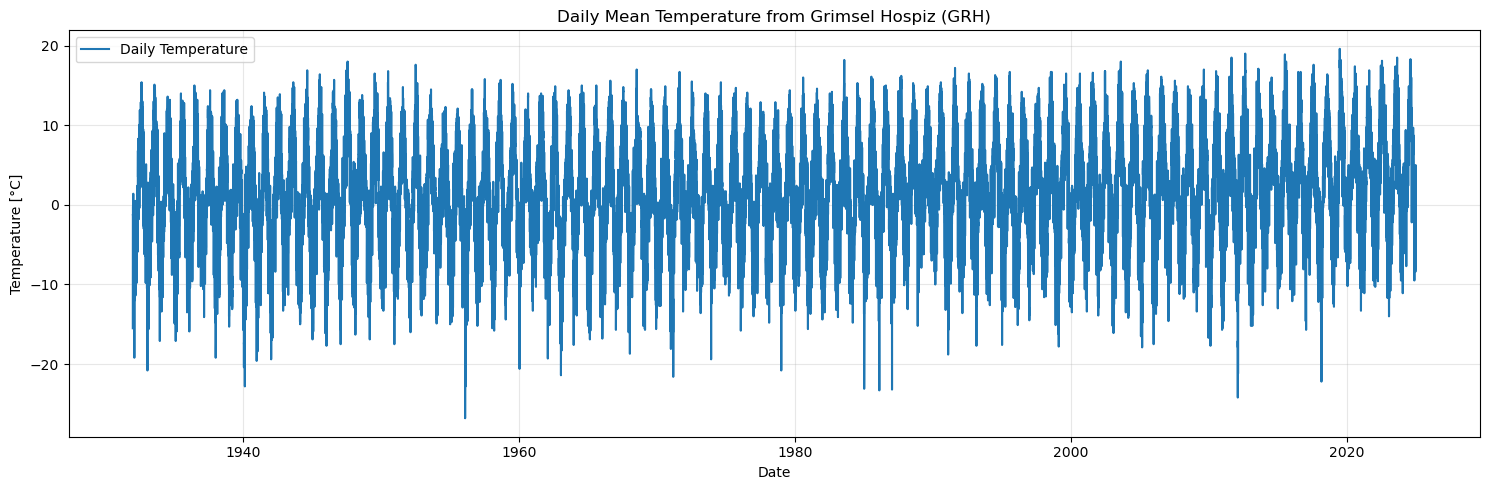

In [3]:
temperature_file = 'data/ogd-nbcn_grh_d_historical.csv'

df_temperature = pd.read_csv(temperature_file, sep=';')
df_temperature["datum"] = pd.to_datetime(df_temperature["reference_timestamp"], dayfirst=True)
df_temperature["temperature"] = pd.to_numeric(df_temperature["ths200d0"].astype(str).str.replace(",", "."))
df_temperature = df_temperature.dropna(subset=["datum", "temperature"])
df_temperature = df_temperature.set_index("datum").sort_index()

plt.figure(figsize=(15, 5))
plt.plot(df_temperature.index, df_temperature["temperature"].values, label = "Daily Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature [°C]")
plt.title(f"Daily Mean Temperature from Grimsel Hospiz (GRH)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()

### Precipitation

/var/folders/4r/myg3jzhx1yd72kbqs5r4rv2w0000gn/T/ipykernel_20396/2757820325.py:3: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df_precipitation = pd.read_csv(precipitation_file, sep=',', quoting=3, dtype=str, encoding='latin1', index_col=False)


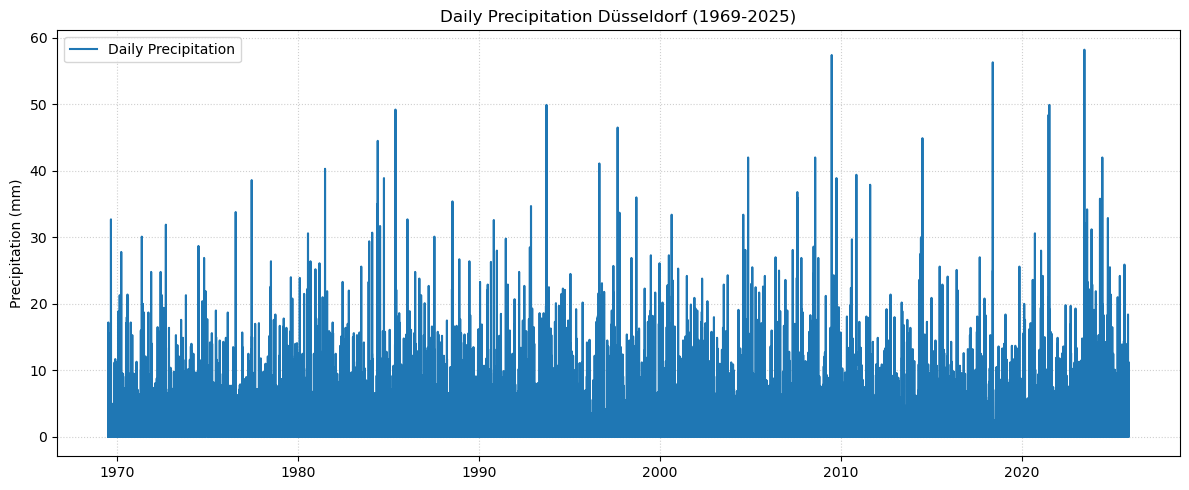

In [4]:
precipitation_file = 'data/dusseldorf_precipitation.csv'

df_precipitation = pd.read_csv(precipitation_file, sep=',', quoting=3, dtype=str, encoding='latin1', index_col=False)
df_precipitation.columns = df_precipitation.columns.str.replace('"', '').str.strip()
df_precipitation = df_precipitation.replace('"', '', regex=True)

date_col = 'Zeitstempel'
val_col = 'Wert'

df_precipitation[date_col] = pd.to_datetime(df_precipitation[date_col], format='%Y-%m-%d', errors='coerce')
df_precipitation[val_col] = pd.to_numeric(df_precipitation[val_col], errors='coerce')

df_precipitation = df_precipitation.dropna(subset=[date_col, val_col])
df_precipitation.set_index(date_col, inplace=True)
df_precipitation = df_precipitation[df_precipitation[val_col] >= 0]  
df_precipitation = df_precipitation.asfreq('D', fill_value=0.0)

# 5. Plotting
plt.figure(figsize=(12, 5))
plt.plot(df_precipitation.index, df_precipitation[val_col], label='Daily Precipitation')

plt.title(f'Daily Precipitation Düsseldorf ({df_precipitation.index.year.min()}-{df_precipitation.index.year.max()})')
plt.ylabel('Precipitation (mm)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


### Groundwater Level

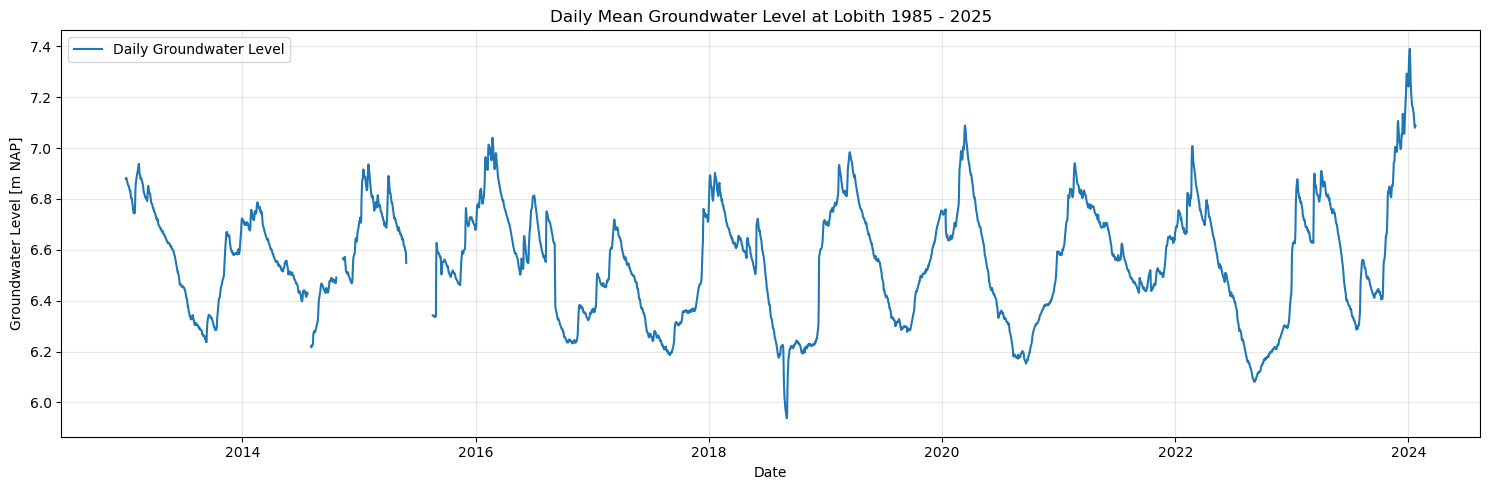

In [5]:
groundwater_file = 'data/groundwater.csv'

df_gw = pd.read_csv(groundwater_file, delimiter=';')
df_gw['meetwaarde (m NAP)'] = df_gw['meetwaarde (m NAP)'] / 100
df_gw['date'] = pd.to_datetime(df_gw['datum'] + ' ' + df_gw['tijd'], dayfirst=True)
df_gw = df_gw.set_index('date')
df_gw = df_gw.drop(columns=['datum', 'tijd'])
df_gw = df_gw.resample('D').mean()

plt.figure(figsize=(15, 5))
plt.plot(df_gw.index, df_gw['meetwaarde (m NAP)'], label = "Daily Groundwater Level")
plt.xlabel("Date")
plt.ylabel("Groundwater Level [m NAP]")
plt.title("Daily Mean Groundwater Level at Lobith 1985 - 2025")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()

### Combine Datasets into One Single Dataframe

To effectively combine all datasets into one single dataframe, the overlapping datapoints have to be found. 

In [6]:
def get_clean_series(data, new_name):
    """
    Takes a DataFrame, Series, or List and returns a clean, named Series.
    Handles grouping duplicates automatically.
    """

    # Handle Duplicates (Group by Date)
    grouped = data.groupby(level=0).mean(numeric_only=True)
    
    # Extract Values
    if isinstance(grouped, pd.DataFrame):
        # Verify we have numeric columns left
        if grouped.shape[1] > 0:
            s = grouped.iloc[:, 0]
        else:
            # Fallback for empty or non-numeric frames
            return pd.Series(name=new_name, dtype='float64')
    else:
        s = grouped
        
    return s.rename(new_name)

s_discharge = get_clean_series(df_discharge, "Discharge_m3s")
s_temp      = get_clean_series(df_temperature, "Temperature_C")
s_precip    = get_clean_series(df_precipitation, "Precipitation_mm")
s_ground    = get_clean_series(df_gw, "Groundwater_m")

df_final = pd.concat([s_discharge, s_temp, s_precip, s_ground], axis=1)
df_final = df_final.sort_index()
df_final = df_final.dropna()

## NPBN Analysis

### DAG (Directed Acyclic Graph)

In [7]:
N = df_final.shape[1] 
parents1 = [None]*N  

parents1[0] = []   # Discharge has no parents       
parents1[1] = [0]  # Temperature is the parent of Discharge          
parents1[2] = [0]  # Precipitation is the parent of Discharge    
parents1[3] = [0]  # Groundwater is the parent of Discharge

### No time lag correlation analysis

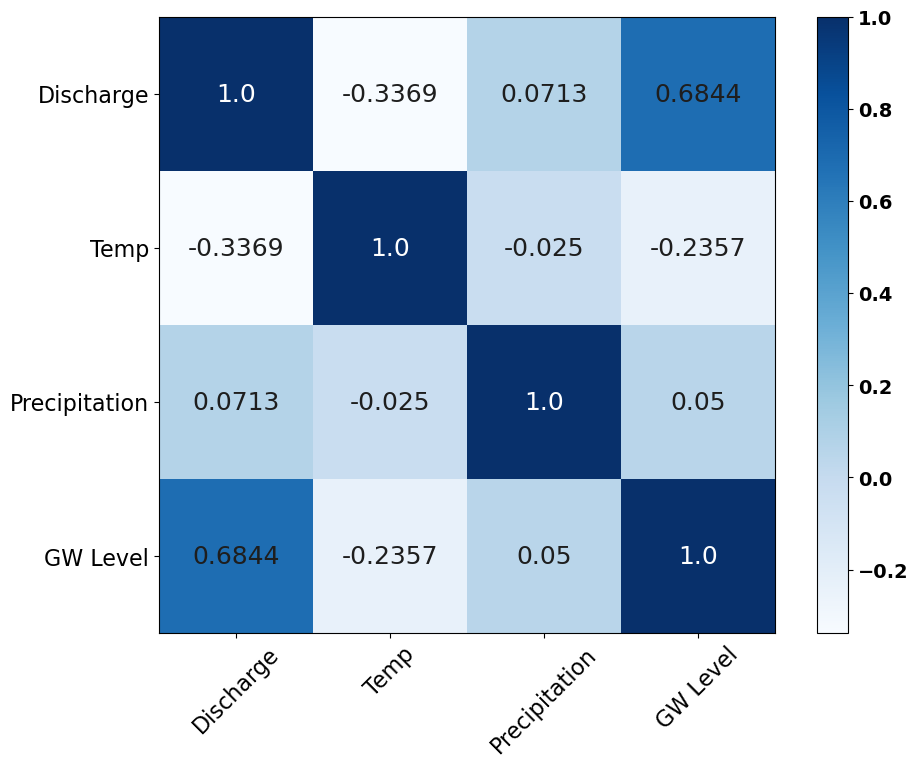

In [8]:
R_BN_1 = bn_rankcorr(parents1, df_final, var_names=['Discharge', 'Temp', 'Precipitation', 'GW Level'], is_data=True, plot=True)

### Time Lag correlation analysis

#### Optimal time lag calculation

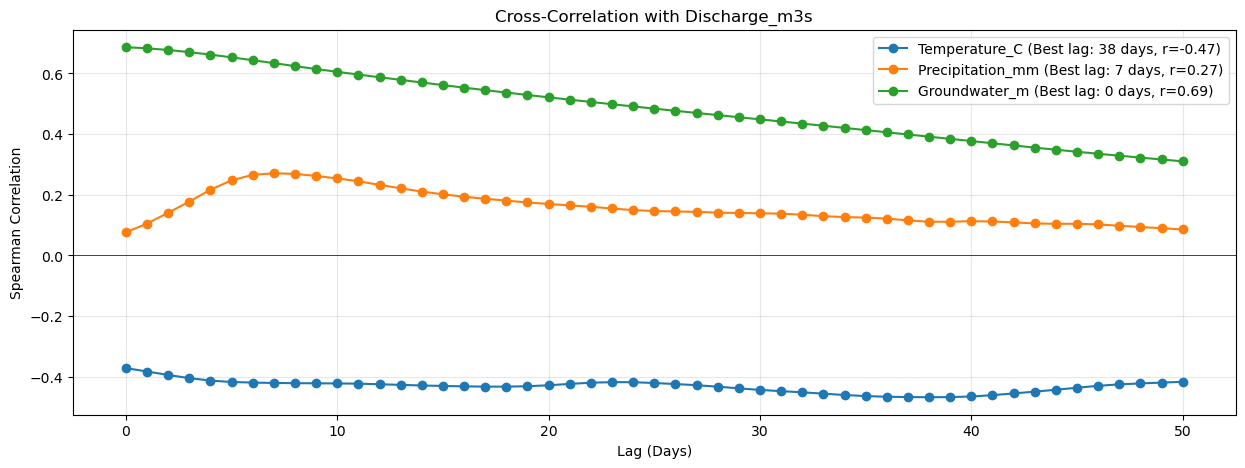

Optimal Shifts Found:
 - Temperature_C: 38 days
 - Precipitation_mm: 7 days
 - Groundwater_m: 0 days


In [9]:
def analyze_lag(df, target, parent, max_lag=50):
    lags = range(max_lag + 1)
    correlations = []
    
    for lag in lags:
        shifted_parent = df[parent].shift(lag)
        corr = df[target].corr(shifted_parent, method='spearman')
        correlations.append(corr)
        
    abs_corrs = [abs(c) for c in correlations]
    best_lag = abs_corrs.index(max(abs_corrs))
    best_corr = correlations[best_lag]
    
    return lags, correlations, best_lag, best_corr

target_var = 'Discharge_m3s'
parents = ['Temperature_C', 'Precipitation_mm', 'Groundwater_m']

plt.figure(figsize=(15, 5))

best_lags = {}

for parent in parents:
    lags, corrs, best_k, max_r = analyze_lag(df_final, target_var, parent)
    best_lags[parent] = best_k
    plt.plot(lags, corrs, marker='o', label=f'{parent} (Best lag: {best_k} days, r={max_r:.2f})')

plt.title(f'Cross-Correlation with {target_var}')
plt.xlabel('Lag (Days)')
plt.ylabel('Spearman Correlation')
plt.axhline(0, color='black', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Optimal Shifts Found:")
for p, k in best_lags.items():
    print(f" - {p}: {k} days")

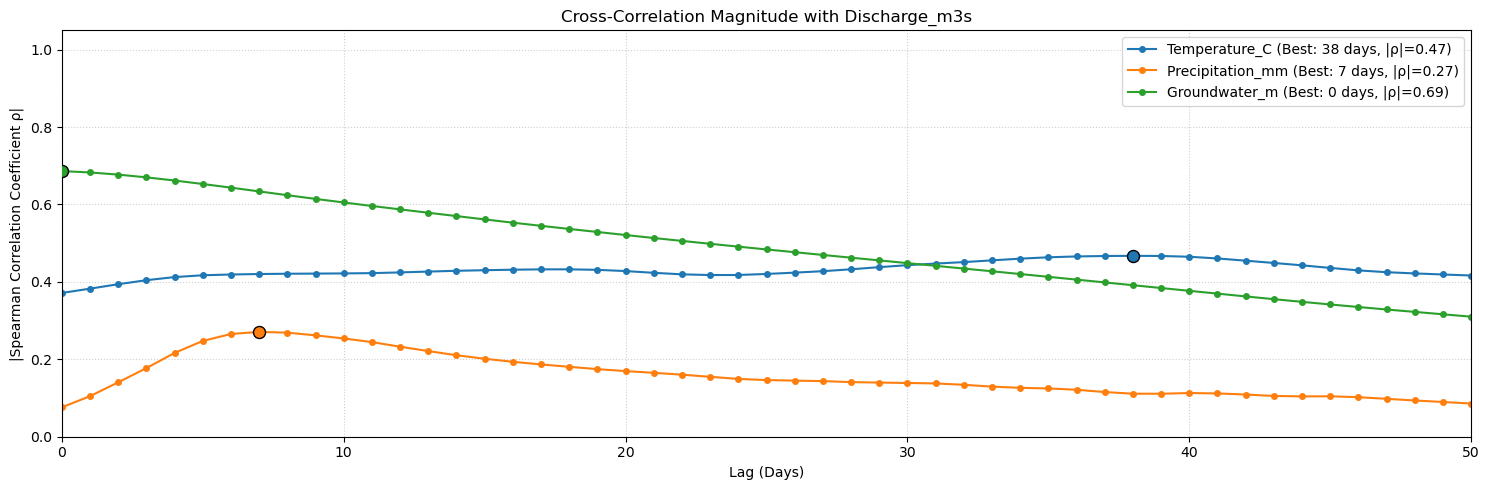

Optimal Shifts Found:
 - Temperature_C: 38 days
 - Precipitation_mm: 7 days
 - Groundwater_m: 0 days


In [10]:
def analyze_lag(df, target, parent, max_lag=50):
    lags = range(max_lag + 1)
    correlations = []
    
    for lag in lags:
        # Shift parent data "down" by lag days
        shifted_parent = df[parent].shift(lag)
        
        # Calculate Spearman correlation
        corr = df[target].corr(shifted_parent, method='spearman')
        correlations.append(corr)
        
    # Take absolute values for analysis and plotting
    abs_corrs = [abs(c) for c in correlations]
    
    # Find best lag based on maximum ABSOLUTE correlation
    best_lag = abs_corrs.index(max(abs_corrs))
    best_corr = abs_corrs[best_lag] # This is now the absolute value
    
    return lags, abs_corrs, best_lag, best_corr

# Configuration
target_var = 'Discharge_m3s'
parents = ['Temperature_C', 'Precipitation_mm', 'Groundwater_m']

# Plotting - Changed figsize to be wider (better for time series/lags)
plt.figure(figsize=(15, 5))

best_lags = {}

for parent in parents:
    lags, abs_corrs, best_k, max_r = analyze_lag(df_final, target_var, parent)
    best_lags[parent] = best_k
    
    # Plot the line
    p = plt.plot(lags, abs_corrs, marker='o', markersize=4, 
                 label=f'{parent} (Best: {best_k} days, |ρ|={max_r:.2f})')
    
    # Highlight the maximum point with a larger dot
    color = p[0].get_color() # Get the color of the line to match
    plt.scatter(best_k, max_r, s=75, color=color, edgecolors='black', zorder=5)

plt.title(f'Cross-Correlation Magnitude with {target_var}')
plt.xlabel('Lag (Days)')
plt.ylabel('|Spearman Correlation Coefficient ρ|')
plt.xlim(0, 50)
plt.ylim(0, 1.05) # Fixed y-axis for cleaner look
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print("Optimal Shifts Found:")
for p, k in best_lags.items():
    print(f" - {p}: {k} days")

#### Calculate correlations with shifted timeseries

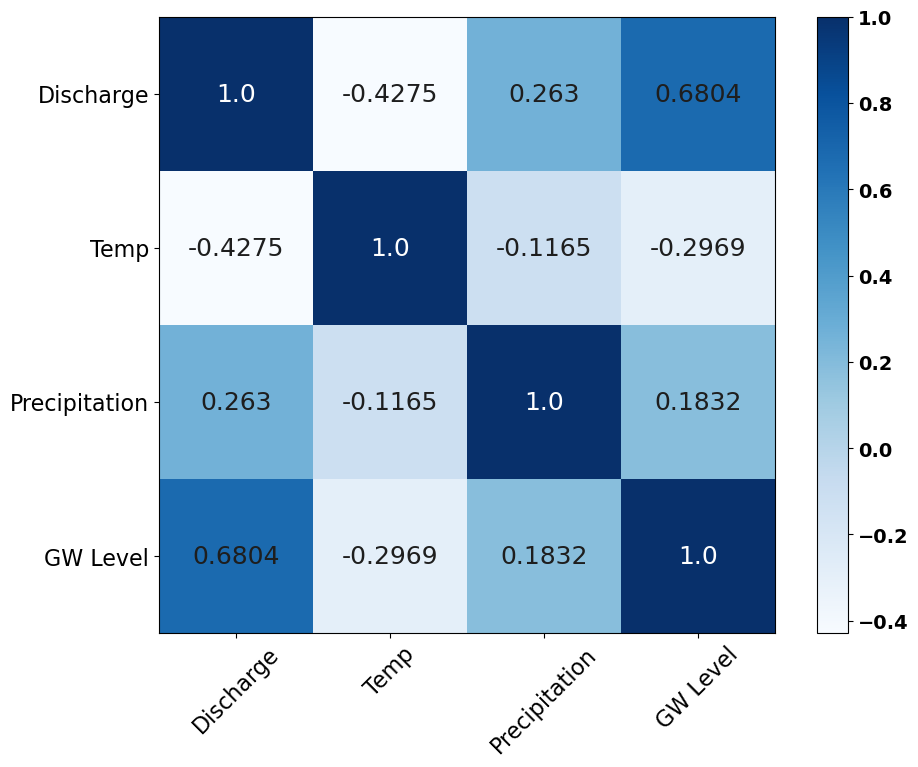

In [11]:
df_shifted = df_final.copy()

for col, lag in best_lags.items():
    if lag > 0:
        new_name = f"{col}_lag{lag}"
        df_shifted[col] = df_shifted[col].shift(lag)
    else:
        pass
        
df_shifted = df_shifted.dropna()

R_BN_1_shifted = bn_rankcorr(parents1, df_shifted, var_names=['Discharge', 'Temp', 'Precipitation', 'GW Level'], is_data=True, plot=True)

### Check if the use of NPBN is justified

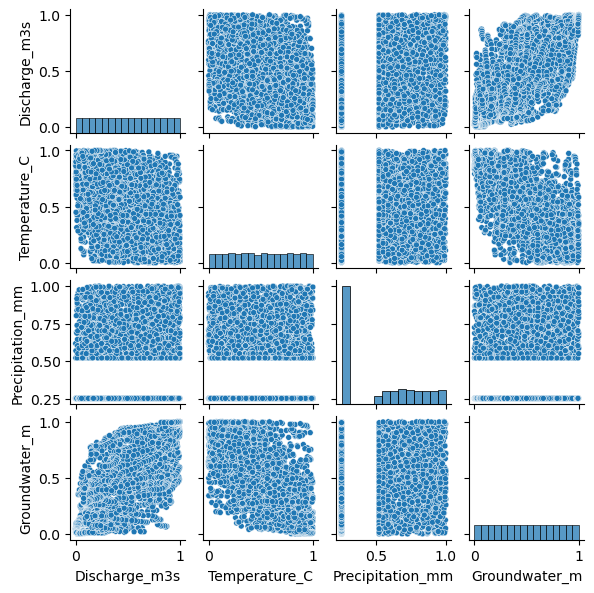

In [12]:
data = df_shifted

def unity(data):
    u_hat = stats.rankdata(data, method='average', axis=0)
    u_hat = u_hat / (data.shape[0] + 1)
    return pd.DataFrame(u_hat, columns=data.columns)

unity_data = unity(data)
sns.pairplot(unity_data, height=1.5,plot_kws=dict(size=.1))

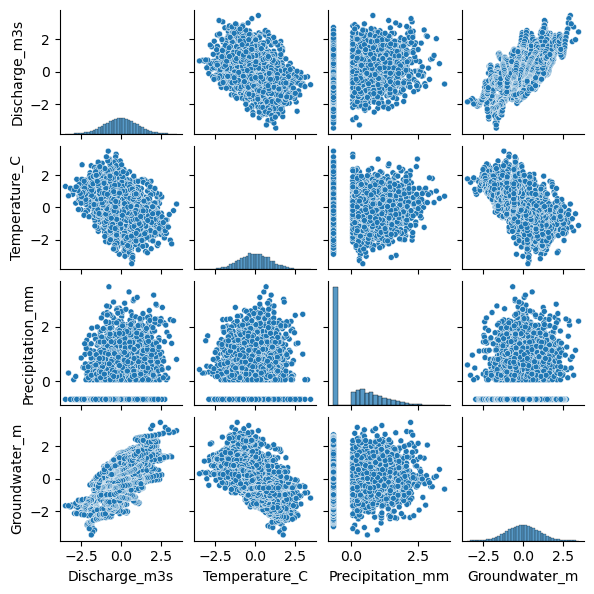

In [13]:
def sd_normal(data):
    u_hat = stats.rankdata(data, method='average', axis=0) / (len(data) + 1)
    sd_data = stats.norm.ppf(u_hat) # norm.ppf is the inverse of the CDF!!
    return sd_data

sd_data = pd.DataFrame(sd_normal(data), columns = data.columns)
sns.pairplot(sd_data, height=1.5,plot_kws=dict(size=.1))

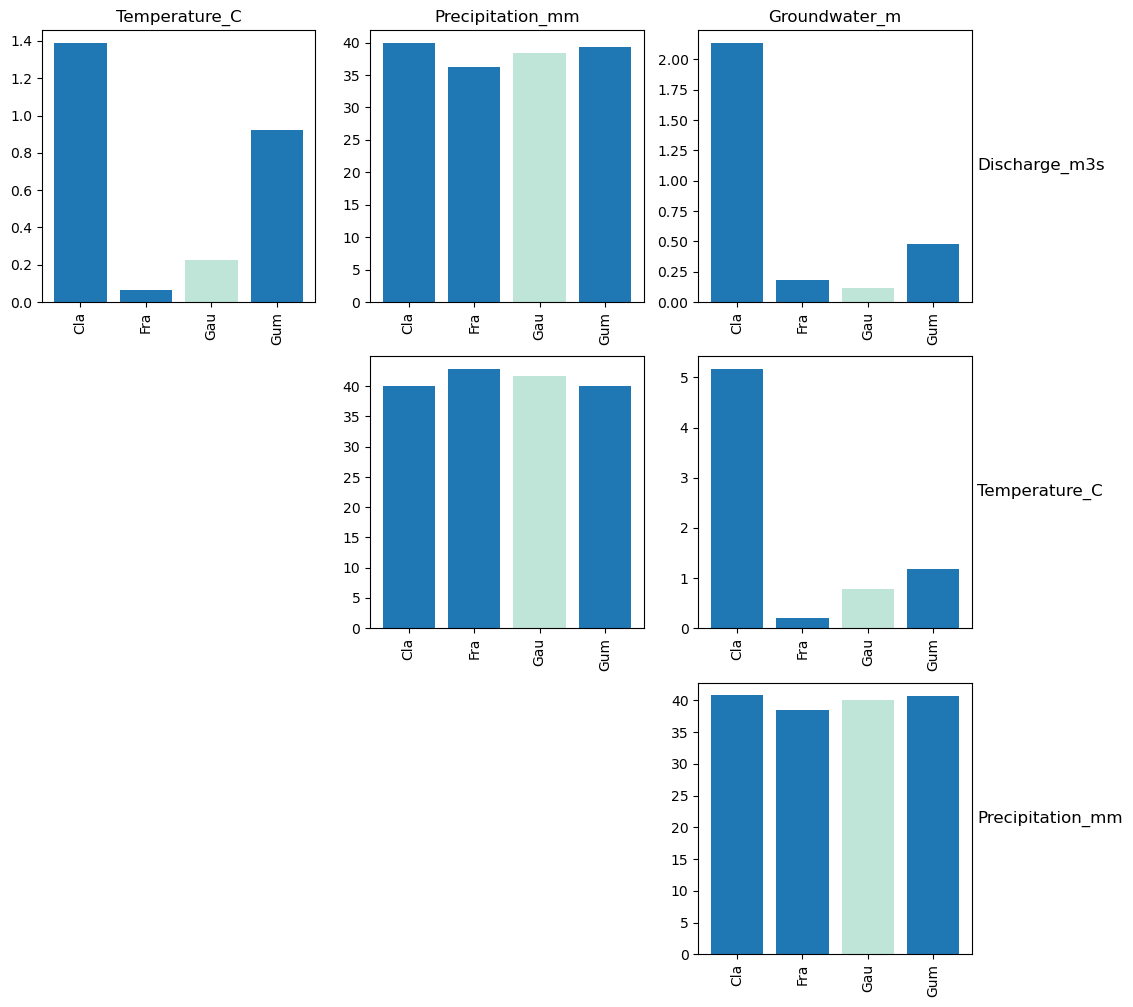

In [14]:
import warnings  
warnings.filterwarnings("ignore")

M = cvm_statistic(data, plot=1, names=data.columns,fig_name='CvM')

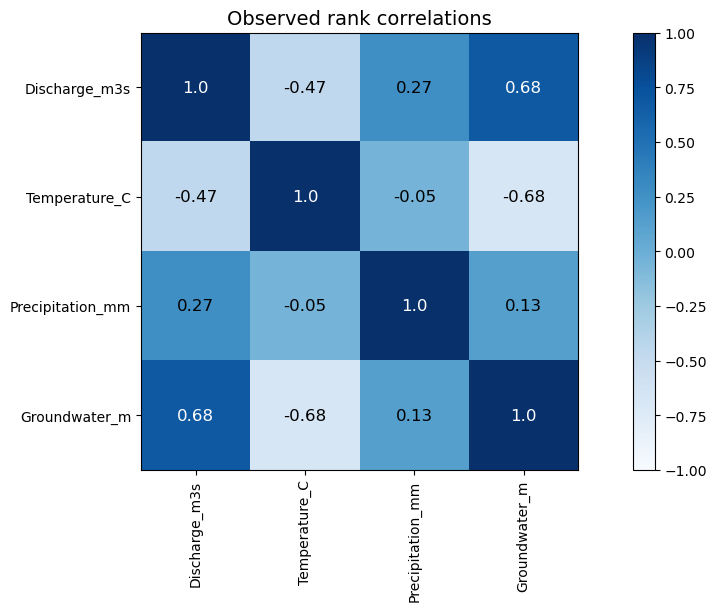

In [15]:
R_e = stats.spearmanr(data)[0]
nam = data.columns
px = list(range(len(nam)))

fig, axes = plt.subplots(1,1, figsize=(15,6), layout='constrained')
im1=axes.imshow(R_e, cmap='Blues', vmin=-1, vmax=1)
axes.set_xticks(px, nam, rotation=90)
axes.set_yticks(px, nam)
axes.set_title('Observed rank correlations',fontsize=14)
zz2 = np.round(R_e, 2)
zz = zz2.astype(str)
for i in range(len(nam)):
    for j in range(len(nam)):
        if zz2[i,j]>0.5:
            color = 'w'
        else:
            color = 'k'
        axes.text(j, i, zz[i, j],
                        ha="center", va="center",
                        fontsize=12, color=color)
cbar = fig.colorbar(im1,ax=axes, fraction=0.05, pad=0.04)

In [16]:
#Transform data to standard normal and store it in a DataFrame
standard_data = pd.DataFrame(sd_normal(data), columns=data.columns)

#Compute pearson correlation matrix
rho_N = np.corrcoef(standard_data, rowvar=False) # PEARSON!

#Transform to rank correlation matrix
R_N = 6 / np.pi * np.arcsin(rho_N / 2)

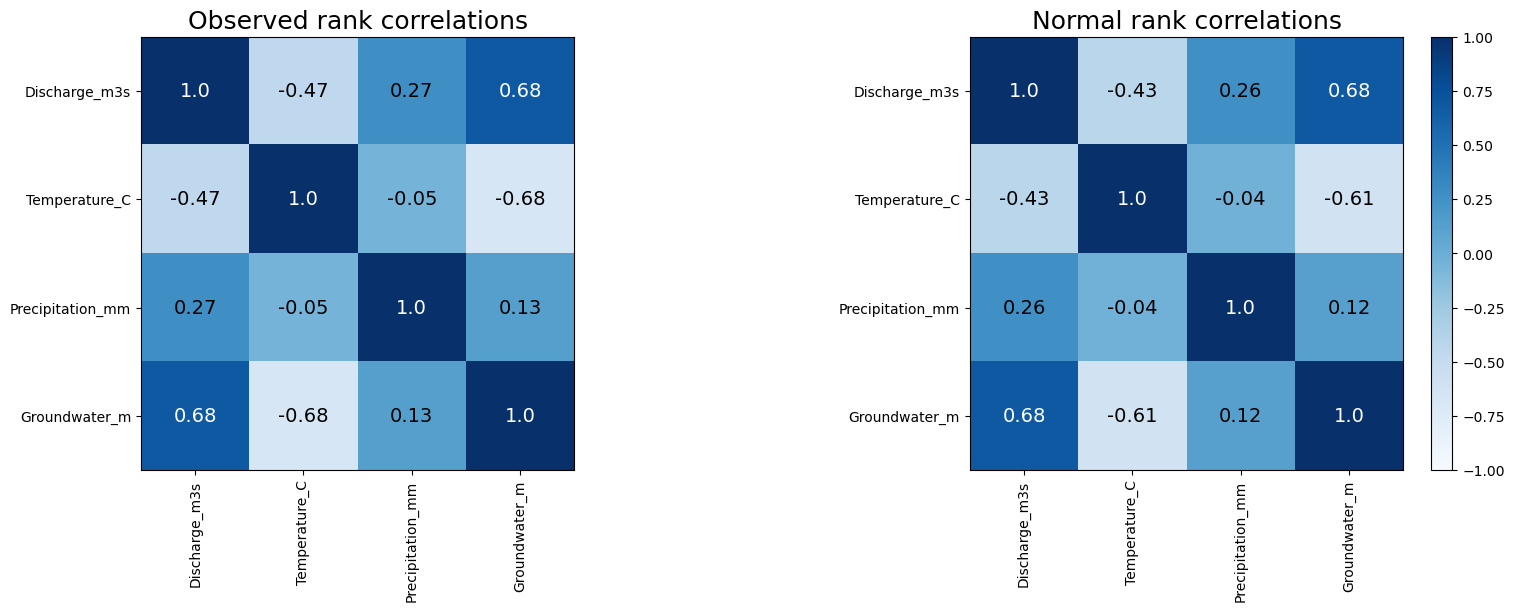

In [17]:
#Plot
nam = data.columns
px = list(range(len(nam)))

fig, axes = plt.subplots(1,2, figsize=(15,6), layout='constrained')
im1=axes[0].imshow(R_e, cmap='Blues', vmin=-1, vmax=1)
axes[0].set_xticks(px, nam, rotation=90)
axes[0].set_yticks(px, nam)
axes[0].set_title('Observed rank correlations',fontsize=18)
zz2 = np.round(R_e, 2)
zz = zz2.astype(str)
for i in range(len(nam)):
    for j in range(len(nam)):
        if zz2[i,j]>0.5:
            color = 'w'
        else:
            color = 'k'
        axes[0].text(j, i, zz[i, j],
                        ha="center", va="center",
                        fontsize=14, color=color)

im1=axes[1].imshow(R_N, cmap='Blues', vmin=-1, vmax=1)
axes[1].set_xticks(px, nam, rotation=90)
axes[1].set_yticks(px, nam)
axes[1].set_title('Normal rank correlations',fontsize=18)
zz2 = np.round(R_N, 2)
zz = zz2.astype(str)
for i in range(len(nam)):
    for j in range(len(nam)):
        if zz2[i,j]>0.5:
            color = 'w'
        else:
            color = 'k'
        axes[1].text(j, i, zz[i, j],
                        ha="center", va="center",
                        fontsize=14, color=color)
        
cbar = fig.colorbar(im1,ax=axes[1], fraction=0.05, pad=0.04)

## Simulating Flood Events

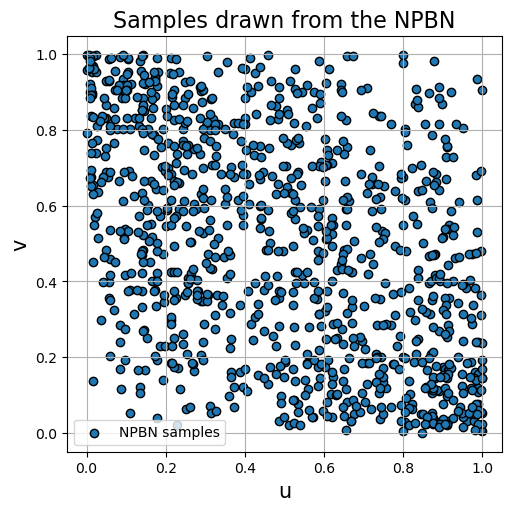

In [18]:
distributions_vars = ['uniform', 'uniform', 'uniform', 'uniform']
parameters_vars = [[0, 1], [0, 1], [0,1], [0,1]]

samples_BN = generate_samples(R=R_BN_1_shifted,
                              n=1000,
                              names=['Discharge', 'Temp', 'Precipitation', 'GW Level'],
                              data=[],
                              empirical_data=False,
                              distributions=distributions_vars,
                              parameters=parameters_vars)


fig, axes = plt.subplots(1,1, figsize=(5,5), layout='constrained')
axes.scatter(samples_BN.iloc[:, 0], samples_BN.iloc[:, 1], edgecolor='k', label ='NPBN samples')
axes.set_xlabel('u',fontsize=15)
axes.set_ylabel('v',fontsize=15)
axes.set_title('Samples drawn from the NPBN',fontsize=16)
axes.legend()
axes.grid()

## Rain with system memory (6 days)

In [19]:
df_precipitation_system_memory = df_precipitation.copy()
df_precipitation_system_memory['Wert'] = df_precipitation_system_memory['Wert'].rolling(window=6, min_periods=1).sum()
s_precip_system_memory    = get_clean_series(df_precipitation_system_memory, "Wert")
df_final_system_memory = pd.concat([s_discharge, s_temp, s_precip_system_memory, s_ground], axis=1)
df_final_system_memory = df_final_system_memory.sort_index()
df_final_system_memory = df_final_system_memory.dropna()

df_final_system_memory.head()

,Discharge_m3s,Temperature_C,Wert,Groundwater_m
2013-01-01,4191.446493,-5.8,22.2,6.879375
2013-01-02,3887.455644,-11.3,13.5,6.883000
2013-01-03,3536.374827,-7.4,13.4,6.881125
2013-01-04,3183.239792,-1.1,13.0,6.872875
2013-01-05,2874.311581,-2.8,11.4,6.868875


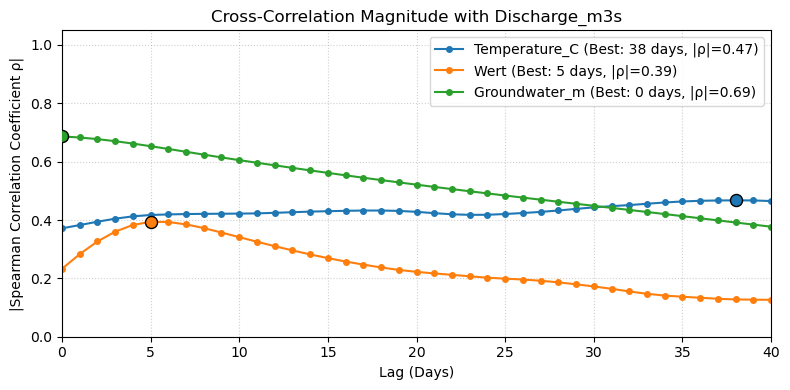

Optimal Shifts Found:
 - Temperature_C: 38 days
 - Wert: 5 days
 - Groundwater_m: 0 days


In [20]:

target_var = 'Discharge_m3s'
parents = ['Temperature_C', 'Wert', 'Groundwater_m'] 

plt.figure(figsize=(8, 4))

best_lags = {}

for parent in parents:
    if parent not in df_final_system_memory.columns:
        print(f"Warning: Column '{parent}' not found. Skipping.")
        continue
        
    lags, abs_corrs, best_k, max_r = analyze_lag(df_final_system_memory, target_var, parent)
    best_lags[parent] = best_k
    
    p = plt.plot(lags, abs_corrs, marker='o', markersize=4, 
                 label=f'{parent} (Best: {best_k} days, |ρ|={max_r:.2f})')
    
    color = p[0].get_color()
    plt.scatter(best_k, max_r, s=75, color=color, edgecolors='black', zorder=5)

plt.title(f'Cross-Correlation Magnitude with {target_var}')
plt.xlabel('Lag (Days)')
plt.ylabel('|Spearman Correlation Coefficient ρ|')
plt.xlim(0, 40)
plt.ylim(0, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print("Optimal Shifts Found:")
for p, k in best_lags.items():
    print(f" - {p}: {k} days")

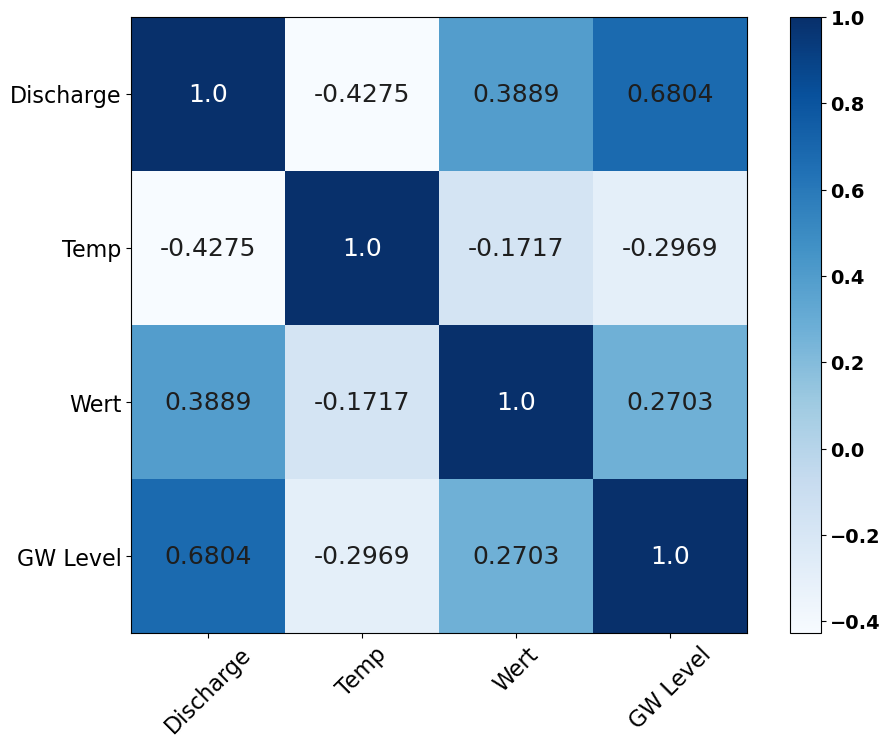

In [21]:
df_shifted_system_memory = df_final_system_memory.copy()

for col, lag in best_lags.items():
    if lag > 0:
        new_name = f"{col}_lag{lag}"
        df_shifted_system_memory[col] = df_shifted_system_memory[col].shift(lag)
    else:
        pass
        
df_shifted_system_memory = df_shifted_system_memory.dropna()
R_BN_1_shifted = bn_rankcorr(parents1, df_shifted_system_memory, var_names=['Discharge', 'Temp', 'Wert', 'GW Level'], is_data=True, plot=True)

## Switch to Snowmelt

Snowmelt data obtained from the ERA5 single levels dataset. taken every 3 hours and resampled to daily mean values. 

In [22]:
df_snowmelt = compile_era5_snowmelt('data/era5_snowmelt')

CSV not found. Processing raw NetCDF files in 'data/era5_snowmelt'...
Processed: era5_waves_2000.nc
Processed: era5_waves_2001.nc
Processed: era5_waves_2002.nc
Processed: era5_waves_2003.nc
Processed: era5_waves_2004.nc
Processed: era5_waves_2005.nc
Processed: era5_waves_2006.nc
Processed: era5_waves_2007.nc
Processed: era5_waves_2008.nc
Processed: era5_waves_2009.nc
Processed: era5_waves_2010.nc
Processed: era5_waves_2011.nc
Processed: era5_waves_2012.nc
Processed: era5_waves_2013.nc
Processed: era5_waves_2014.nc
Processed: era5_waves_2015.nc
Processed: era5_waves_2016.nc
Processed: era5_waves_2017.nc
Processed: era5_waves_2018.nc
Processed: era5_waves_2019.nc
Processed: era5_waves_2020.nc
Processed: era5_waves_2021.nc
Processed: era5_waves_2022.nc
Processed: era5_waves_2023.nc
Processed: era5_waves_2024.nc
Processed: era5_waves_2025.nc
Processed: era5_waves_1970.nc
Processed: era5_waves_1971.nc
Processed: era5_waves_1972.nc
Processed: era5_waves_1973.nc
Processed: era5_waves_1974.nc


,smlt
date,
1970-01-01,0.0
1970-01-02,0.0
1970-01-03,0.0
1970-01-04,0.0
1970-01-05,0.0


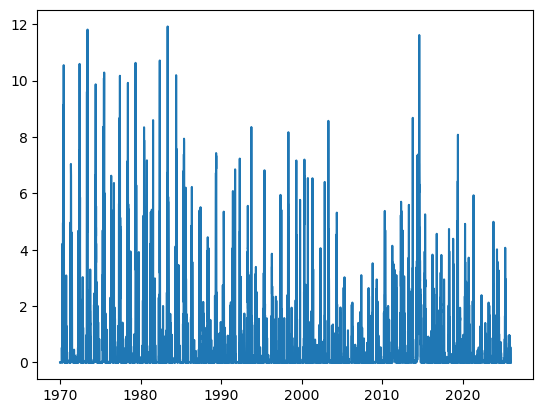

In [23]:
df_snowmelt['valid_time'] = pd.to_datetime(df_snowmelt['valid_time'])
df_snowmelt = df_snowmelt.drop(columns=['number', 'expver', 'source_year'], errors='ignore')
df_snowmelt = df_snowmelt.groupby('valid_time')[['smlt']].mean()
df_snowmelt = df_snowmelt.resample('D').sum()
df_snowmelt.index.name = 'date'
df_snowmelt = df_snowmelt.sort_index()
df_snowmelt['smlt'] = df_snowmelt['smlt'] * 1000            # resample to mm instead of meters

s_snowmelt = get_clean_series(df_snowmelt, "Snowmelt")

display(df_snowmelt.head())

plt.plot(df_snowmelt.index, df_snowmelt['smlt'], label='Daily Snowmelt (mm)')

#### Rolling sum for snowmelt

In [24]:
df_snowmelt['smlt'] = df_snowmelt['smlt'].rolling(window=5, min_periods=1).sum()
s_snowmelt = get_clean_series(df_snowmelt, "Snowmelt")

df_final_seasonality = pd.concat([s_discharge, s_snowmelt, s_precip_system_memory, s_ground], axis=1)
df_final_seasonality = df_final_seasonality.rename(columns={'Wert': 'Precipitation'})
df_final_seasonality = df_final_seasonality.sort_index()
df_final_seasonality = df_final_seasonality.dropna()

display(df_final_seasonality.tail())

,Discharge_m3s,Snowmelt,Precipitation,Groundwater_m
2024-01-19,1863.441533,0.0,5.6,7.105875
2024-01-20,1981.255619,0.0,5.1,7.088542
2024-01-21,2214.327635,0.0,5.6,7.080083
2024-01-22,2409.018741,0.0,6.4,7.085750
2024-01-23,2433.996869,0.0,5.4,7.088286


In [25]:
# ## Seasonality
# df_final_seasonality = pd.concat([s_discharge, s_snowmelt, s_precip_system_memory, s_ground], axis=1)
# df_final_seasonality = df_final_seasonality.sort_index()
# df_final_seasonality = df_final_seasonality.dropna()

# display(df_final_seasonality.head())

#### Whole year

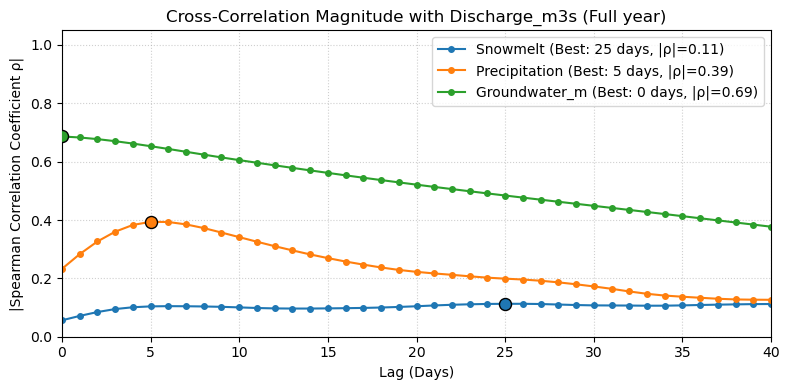

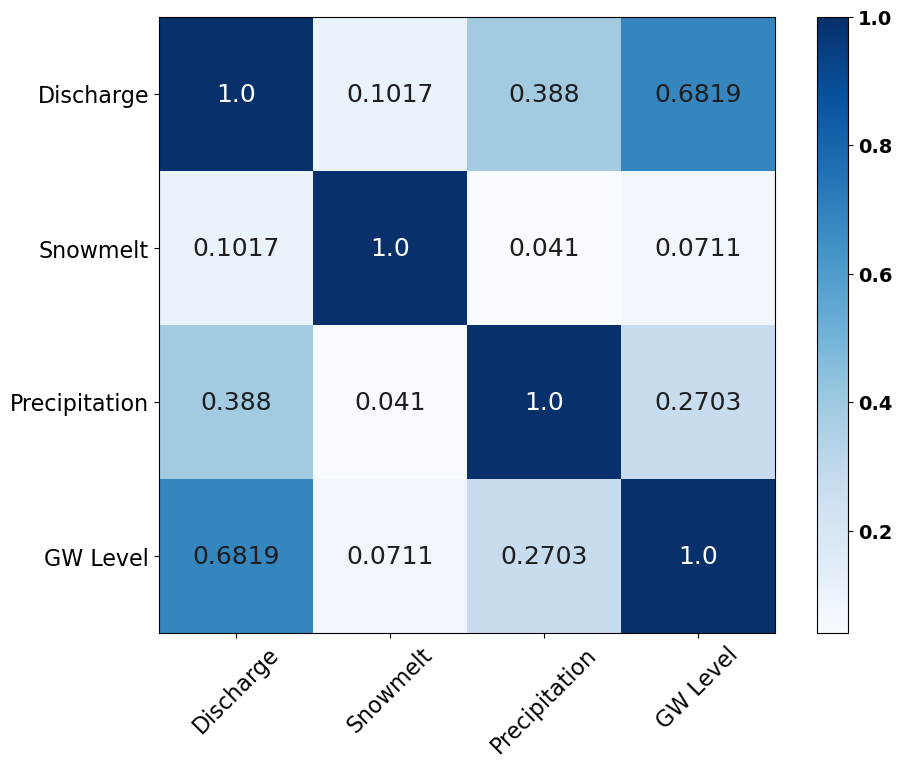

Optimal Shifts Found:
 - Snowmelt: 25 days
 - Precipitation: 5 days
 - Groundwater_m: 0 days


In [26]:
# Whole year 
N = df_final.shape[1] 
parents1 = [None]*N  

parents1[0] = []   # Discharge has no parents       
parents1[1] = [0]  # Temperature is the parent of Discharge          
parents1[2] = [0]  # Precipitation is the parent of Discharge    
parents1[3] = [0]  # Groundwater is the parent of Discharge

target_var = 'Discharge_m3s'
parents = ['Snowmelt', 'Precipitation', 'Groundwater_m'] 

plt.figure(figsize=(8, 4))

best_lags = {}

for parent in parents:
    if parent not in df_final_seasonality.columns:
        print(f"Warning: Column '{parent}' not found. Skipping.")
        continue
        
    lags, abs_corrs, best_k, max_r = analyze_lag(df_final_seasonality, target_var, parent)
    best_lags[parent] = best_k
    
    p = plt.plot(lags, abs_corrs, marker='o', markersize=4, 
                 label=f'{parent} (Best: {best_k} days, |ρ|={max_r:.2f})')
    
    color = p[0].get_color()
    plt.scatter(best_k, max_r, s=75, color=color, edgecolors='black', zorder=5)

df_shifted_seasonality = df_final_seasonality.copy()

for col, lag in best_lags.items():
    if lag > 0:
        new_name = f"{col}_lag{lag}"
        df_shifted_seasonality[col] = df_shifted_seasonality[col].shift(lag)
    else:
        pass
        
df_shifted_seasonality = df_shifted_seasonality.dropna()
plt.title(f'Cross-Correlation Magnitude with {target_var} (Full year)')
plt.xlabel('Lag (Days)')
plt.ylabel('|Spearman Correlation Coefficient ρ|')
plt.xlim(0, 40)
plt.ylim(0, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show

R_BN_1_seasonality_full_year = bn_rankcorr(parents1, df_shifted_seasonality, var_names=['Discharge', 'Snowmelt', 'Precipitation', 'GW Level'], is_data=True, plot=True)

print("Optimal Shifts Found:")
for p, k in best_lags.items():
    print(f" - {p}: {k} days")


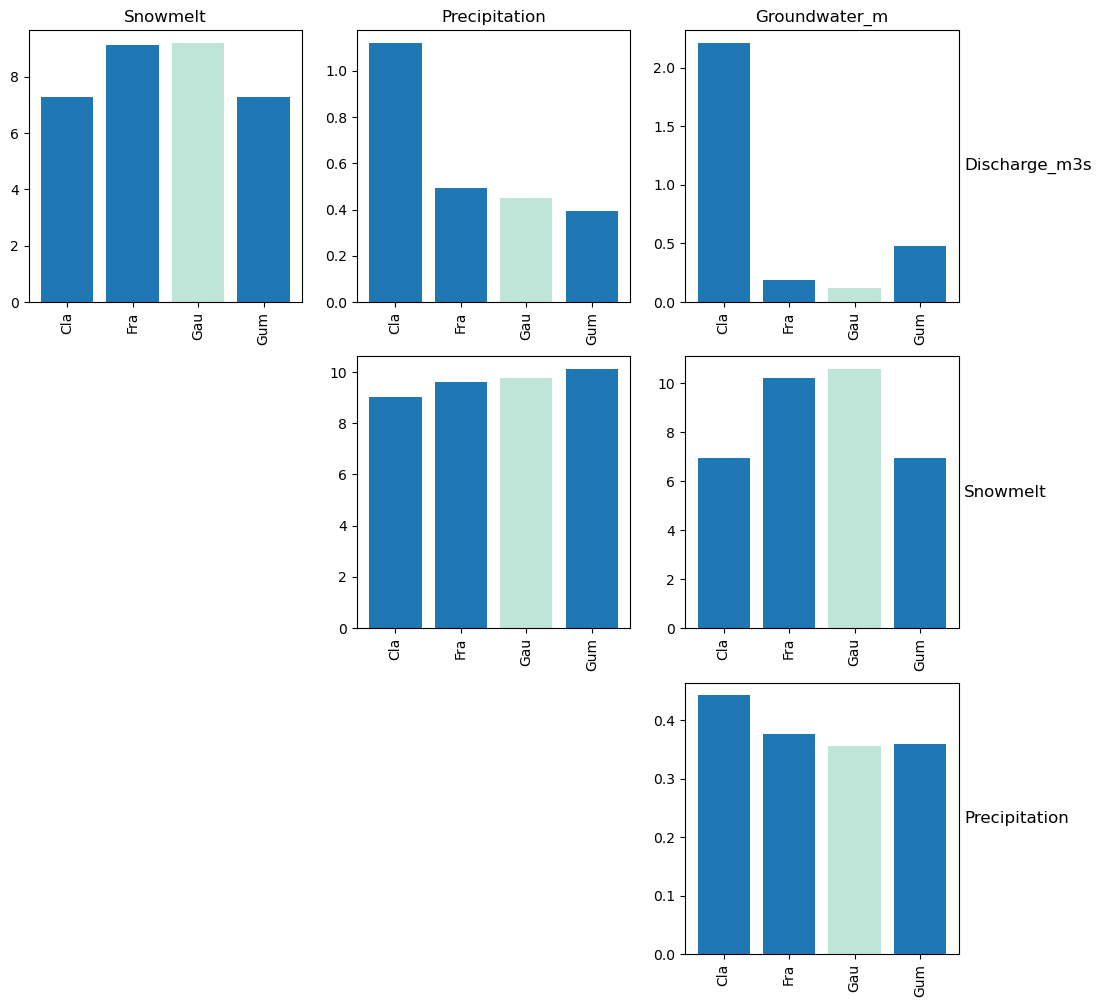

            Discharge_m3s  Snowmelt  Precipitation  Groundwater_m
2013-01-01    4191.446493  0.000000           22.2       6.879375
2013-01-02    3887.455644  0.000000           13.5       6.883000
2013-01-03    3536.374827  0.000000           13.4       6.881125
2013-01-04    3183.239792  0.006711           13.0       6.872875
2013-01-05    2874.311581  0.012208           11.4       6.868875
...                   ...       ...            ...            ...
2024-01-19    1863.441533  0.000000            5.6       7.105875
2024-01-20    1981.255619  0.000000            5.1       7.088542
2024-01-21    2214.327635  0.000000            5.6       7.080083
2024-01-22    2409.018741  0.000000            6.4       7.085750
2024-01-23    2433.996869  0.000000            5.4       7.088286

[3923 rows x 4 columns]


In [27]:
data = df_final_seasonality
unity_data = unity(data)
# sns.pairplot(unity_data, height=1.5,plot_kws=dict(size=.1))
M = cvm_statistic(data, plot=1, names=data.columns,fig_name='CvM')

print(data)

In [28]:
#Transform data to standard normal and store it in a DataFrame
standard_data = pd.DataFrame(sd_normal(data), columns=data.columns)

#Compute pearson correlation matrix
rho_N = np.corrcoef(standard_data, rowvar=False) # PEARSON!

#Transform to rank correlation matrix
R_N = 6 / np.pi * np.arcsin(rho_N / 2)

R_e = stats.spearmanr(data)[0]

print(f'p-value: {stats.spearmanr(data)[1]}')

display(standard_data.head())

p-value: [[0.00000000e+00 4.28367883e-04 2.86059300e-49 0.00000000e+00]
 [4.28367883e-04 0.00000000e+00 1.01263334e-03 1.86867184e-05]
 [2.86059300e-49 1.01263334e-03 0.00000000e+00 2.64611064e-08]
 [0.00000000e+00 1.86867184e-05 2.64611064e-08 0.00000000e+00]]


,Discharge_m3s,Snowmelt,Precipitation,Groundwater_m
0,2.463430,-1.052525,0.926906,1.524351
1,2.257848,-1.052525,0.399741,1.548260
2,2.045814,-1.052525,0.390072,1.532568
3,1.854200,-0.210428,0.357873,1.490527
4,1.652813,-0.146810,0.242215,1.475184


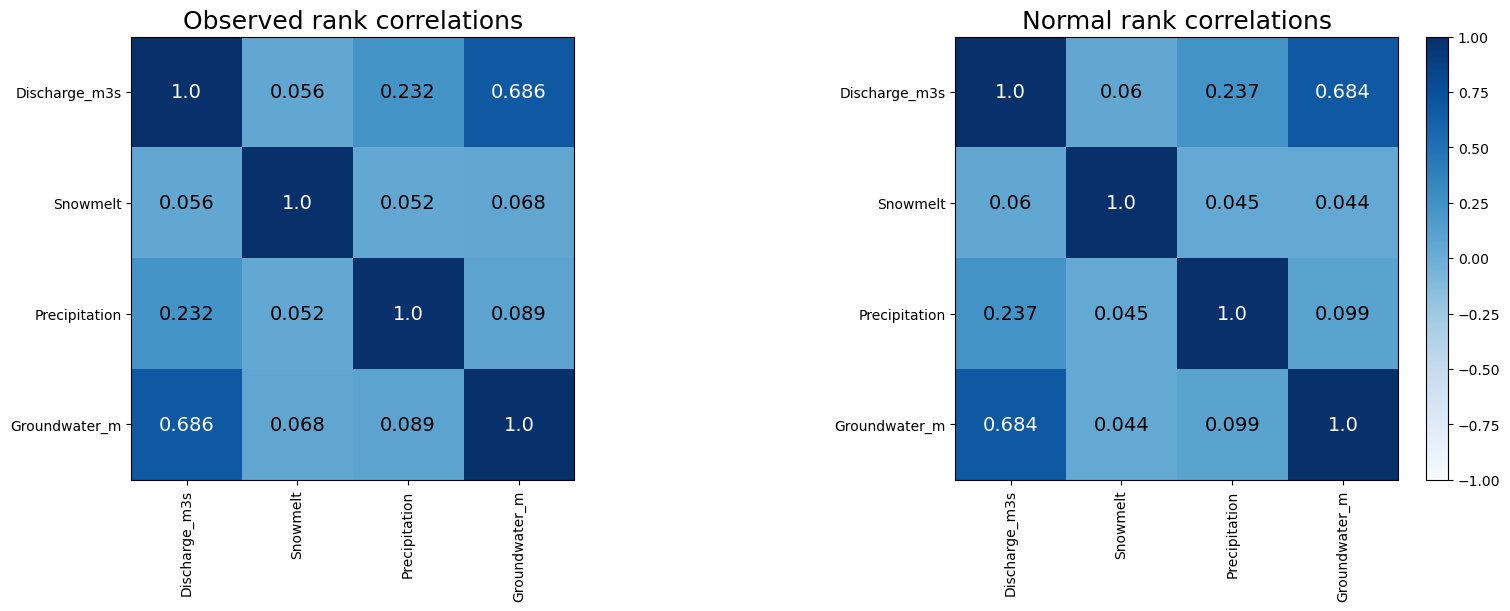

In [29]:
#Plot
nam = data.columns
px = list(range(len(nam)))

fig, axes = plt.subplots(1,2, figsize=(15,6), layout='constrained')
im1=axes[0].imshow(R_e, cmap='Blues', vmin=-1, vmax=1)
axes[0].set_xticks(px, nam, rotation=90)
axes[0].set_yticks(px, nam)
axes[0].set_title('Observed rank correlations',fontsize=18)
zz2 = np.round(R_e, 3)
zz = zz2.astype(str)
for i in range(len(nam)):
    for j in range(len(nam)):
        if zz2[i,j]>0.5:
            color = 'w'
        else:
            color = 'k'
        axes[0].text(j, i, zz[i, j],
                        ha="center", va="center",
                        fontsize=14, color=color)

im1=axes[1].imshow(R_N, cmap='Blues', vmin=-1, vmax=1)
axes[1].set_xticks(px, nam, rotation=90)
axes[1].set_yticks(px, nam)
axes[1].set_title('Normal rank correlations',fontsize=18)
zz2 = np.round(R_N, 3)
zz = zz2.astype(str)
for i in range(len(nam)):
    for j in range(len(nam)):
        if zz2[i,j]>0.5:
            color = 'w'
        else:
            color = 'k'
        axes[1].text(j, i, zz[i, j],
                        ha="center", va="center",
                        fontsize=14, color=color)
        
cbar = fig.colorbar(im1,ax=axes[1], fraction=0.05, pad=0.04)

In [30]:
d_cal_E_N_full_year = 1 - test_distance(R_e, R_N, 'H', data.shape[1])
print('The d-calibration score between R_e and R_N is', d_cal_E_N_full_year.round(2))
d_cal_BN_N_full_year = 1 - test_distance(R_N, R_BN_1_seasonality_full_year, 'H', data.shape[1])
print('The d-calibration score between R_BN and R_N is', d_cal_BN_N_full_year.round(2))

The d-calibration score between R_e and R_N is [[0.99]]
The d-calibration score between R_BN and R_N is [[0.93]]


### Spring

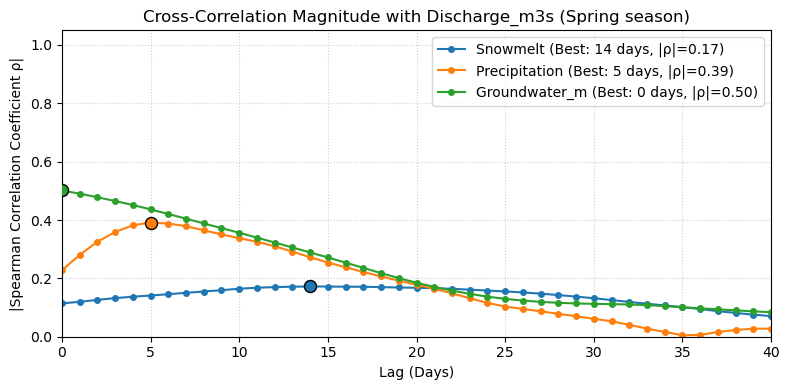

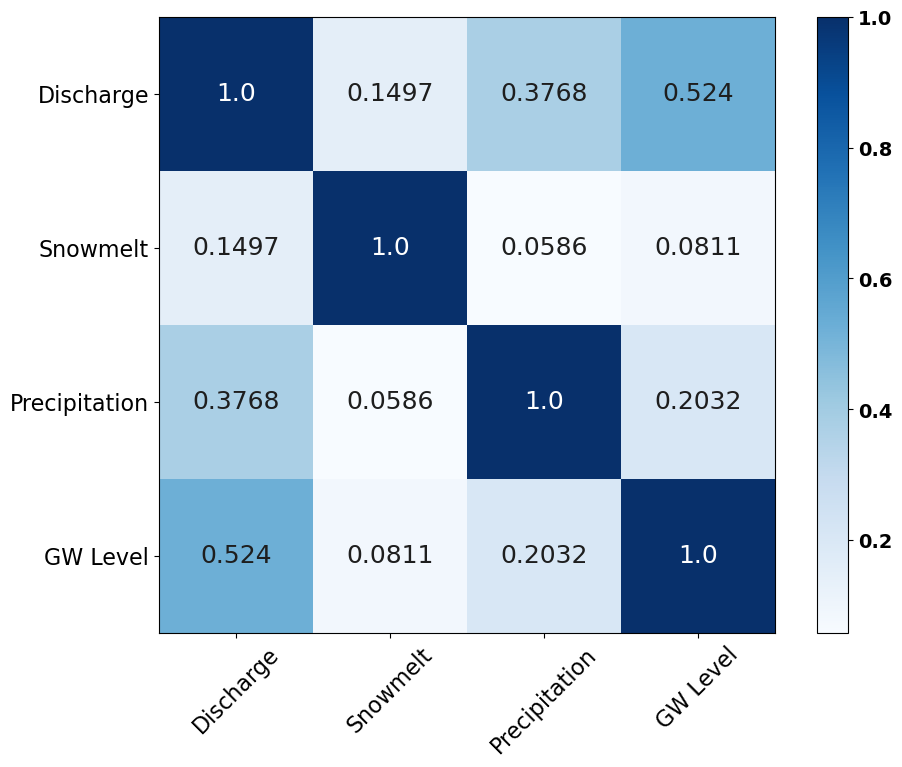

Optimal Shifts Found:
 - Snowmelt: 14 days
 - Precipitation: 5 days
 - Groundwater_m: 0 days


In [31]:
df_spring = df_final_seasonality[df_final_seasonality.index.month.isin([3, 4, 5, 6, 7])].copy()

target_var = 'Discharge_m3s'
parents = ['Snowmelt', 'Precipitation', 'Groundwater_m'] 

plt.figure(figsize=(8, 4))

best_lags = {}

for parent in parents:
    if parent not in df_spring.columns:
        print(f"Warning: Column '{parent}' not found. Skipping.")
        continue
        
    lags, abs_corrs, best_k, max_r = analyze_lag(df_spring, target_var, parent)
    best_lags[parent] = best_k
    
    p = plt.plot(lags, abs_corrs, marker='o', markersize=4, 
                 label=f'{parent} (Best: {best_k} days, |ρ|={max_r:.2f})')
    
    color = p[0].get_color()
    plt.scatter(best_k, max_r, s=75, color=color, edgecolors='black', zorder=5)

df_shifted_spring = df_spring.copy()
for col, lag in best_lags.items():
    if lag > 0:
        new_name = f"{col}_lag{lag}"
        df_shifted_spring[col] = df_shifted_spring[col].shift(lag)
    else:
        pass
        
df_shifted_spring = df_shifted_spring.dropna()
plt.title(f'Cross-Correlation Magnitude with {target_var} (Spring season)')
plt.xlabel('Lag (Days)')
plt.ylabel('|Spearman Correlation Coefficient ρ|')
plt.xlim(0, 40)
plt.ylim(0, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show

R_BN_1_seasonality_spring = bn_rankcorr(parents1, df_shifted_spring, var_names=['Discharge', 'Snowmelt', 'Precipitation', 'GW Level'], is_data=True, plot=True)

print("Optimal Shifts Found:")
for p, k in best_lags.items():
    print(f" - {p}: {k} days")


p-value: [[0.00000000e+000 4.32976817e-006 2.09084123e-020 2.79186509e-103]
 [4.32976817e-006 0.00000000e+000 2.47264163e-001 3.81045667e-026]
 [2.09084123e-020 2.47264163e-001 0.00000000e+000 4.12673789e-001]
 [2.79186509e-103 3.81045667e-026 4.12673789e-001 0.00000000e+000]]


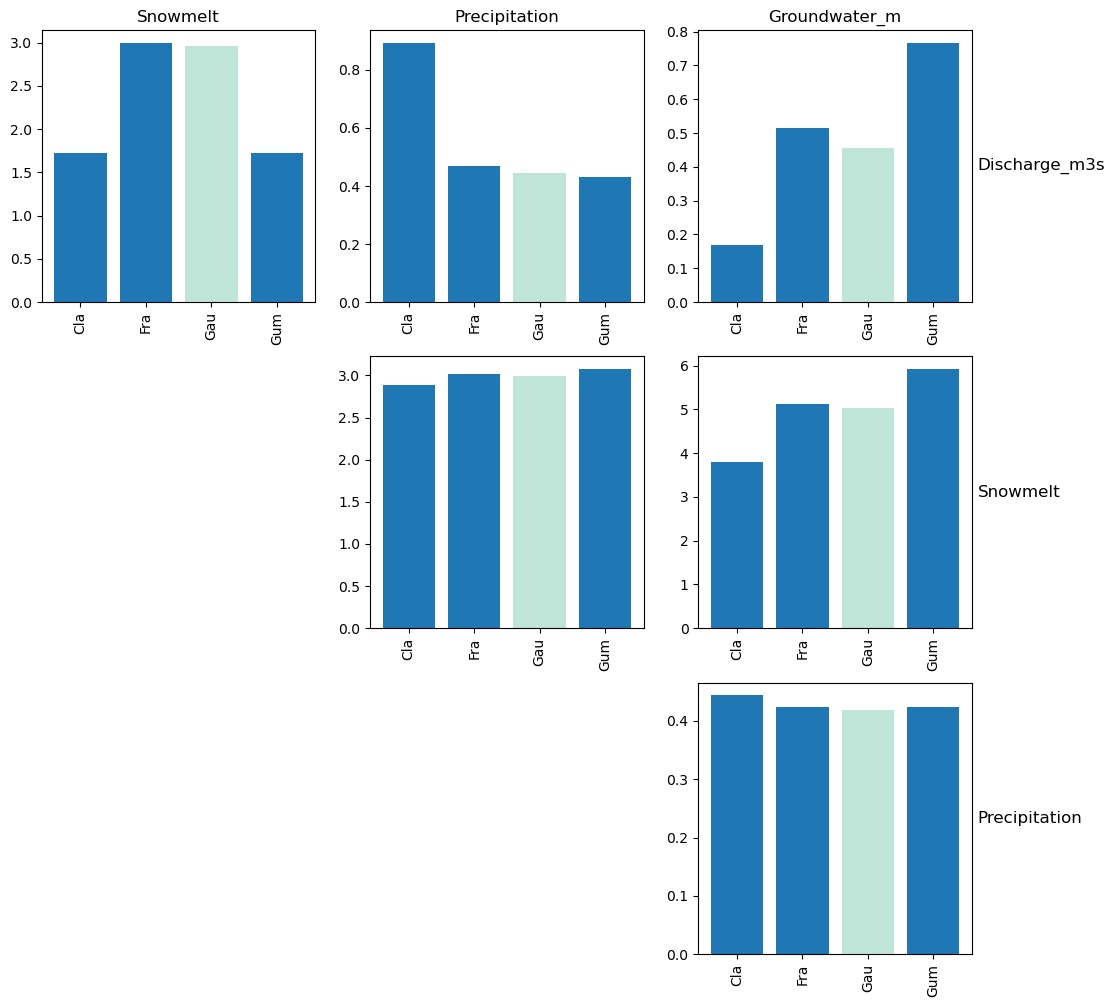

In [32]:
data_spring = df_final_seasonality[df_final_seasonality.index.month.isin([3, 4, 5, 6, 7])].copy()
unity_data_spring = unity(data_spring)

standard_data_spring = pd.DataFrame(sd_normal(data_spring), columns=data_spring.columns)

rho_N_spring = np.corrcoef(standard_data_spring, rowvar=False) # PEARSON!

#Transform to rank correlation matrix
R_N_spring = 6 / np.pi * np.arcsin(rho_N_spring / 2)

R_e_spring = stats.spearmanr(data_spring)[0]

print(f'p-value: {stats.spearmanr(data_spring)[1]}')

M = cvm_statistic(data_spring, plot=1, names=data.columns,fig_name='CvM')

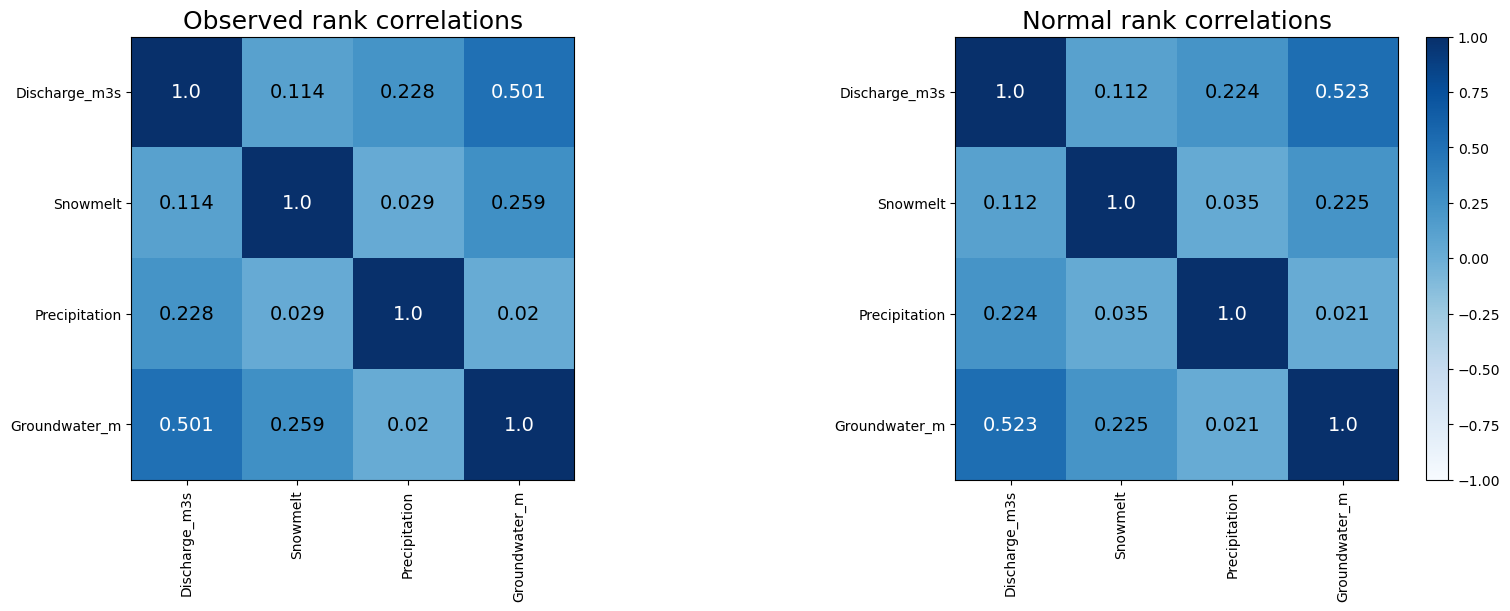

In [33]:
#Plot
nam = data.columns
px = list(range(len(nam)))

fig, axes = plt.subplots(1,2, figsize=(15,6), layout='constrained')
im1=axes[0].imshow(R_e_spring, cmap='Blues', vmin=-1, vmax=1)
axes[0].set_xticks(px, nam, rotation=90)
axes[0].set_yticks(px, nam)
axes[0].set_title('Observed rank correlations',fontsize=18)
zz2 = np.round(R_e_spring, 3)
zz = zz2.astype(str)
for i in range(len(nam)):
    for j in range(len(nam)):
        if zz2[i,j]>0.5:
            color = 'w'
        else:
            color = 'k'
        axes[0].text(j, i, zz[i, j],
                        ha="center", va="center",
                        fontsize=14, color=color)

im1=axes[1].imshow(R_N_spring, cmap='Blues', vmin=-1, vmax=1)
axes[1].set_xticks(px, nam, rotation=90)
axes[1].set_yticks(px, nam)
axes[1].set_title('Normal rank correlations',fontsize=18)
zz2 = np.round(R_N_spring, 3)
zz = zz2.astype(str)
for i in range(len(nam)):
    for j in range(len(nam)):
        if zz2[i,j]>0.5:
            color = 'w'
        else:
            color = 'k'
        axes[1].text(j, i, zz[i, j],
                        ha="center", va="center",
                        fontsize=14, color=color)
        
cbar = fig.colorbar(im1,ax=axes[1], fraction=0.05, pad=0.04)

In [34]:

d_cal_E_N_spring = 1 - test_distance(R_e_spring, R_N_spring, 'H', data_spring.shape[1])
print('The d-calibration score between R_e and R_N is', d_cal_E_N_spring.round(2))

The d-calibration score between R_e and R_N is [[0.98]]


In [35]:
d_cal_BN_N_spring = 1 - test_distance(R_N_spring, R_BN_1_seasonality_spring, 'H', data_spring.shape[1])
print('The d-calibration score between R_BN and R_N is', d_cal_BN_N_spring.round(2))

The d-calibration score between R_BN and R_N is [[0.9]]


### Adjusted plot for better readability

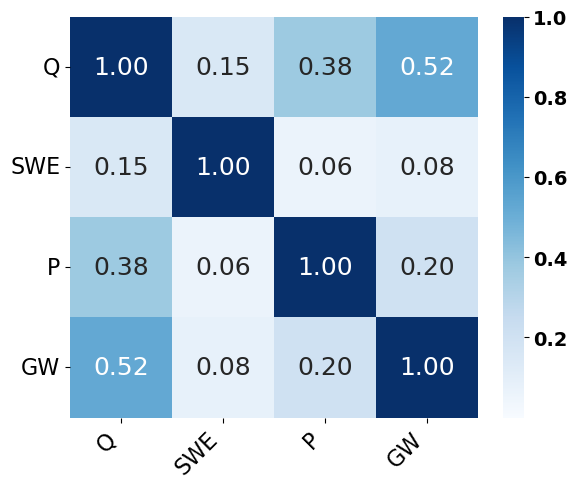

In [36]:
FIG_SIZE = (6, 5)
ANNOT_FONT_SIZE = 18    
AXIS_FONT_SIZE = 16 
CBAR_TICK_SIZE = 14

data_matrix_1 = np.array([
    [1.0, 0.1497, 0.3768, 0.524],
    [0.1497, 1.0, 0.0586, 0.0811],
    [0.3768, 0.0586, 1.0, 0.2032],
    [0.524, 0.0811, 0.2032, 1.0]
])
labels = ['Q', 'SWE', 'P', 'GW']

fig, ax = plt.subplots(figsize=FIG_SIZE)

sns.heatmap(
    data_matrix_1,
    annot=True,
    fmt=".2f",                 
    cmap='Blues',
    vmin=0, vmax=1,
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={'ticks': [0.2, 0.4, 0.6, 0.8, 1.0]},
    annot_kws={"size": ANNOT_FONT_SIZE},
    ax=ax
)

ax.set_xticklabels(labels, fontsize=AXIS_FONT_SIZE, rotation=45, ha='right')
ax.set_yticklabels(labels, fontsize=AXIS_FONT_SIZE, rotation=0)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=CBAR_TICK_SIZE)
for l in cbar.ax.yaxis.get_ticklabels():
    l.set_weight("bold")

plt.tight_layout()
plt.show()

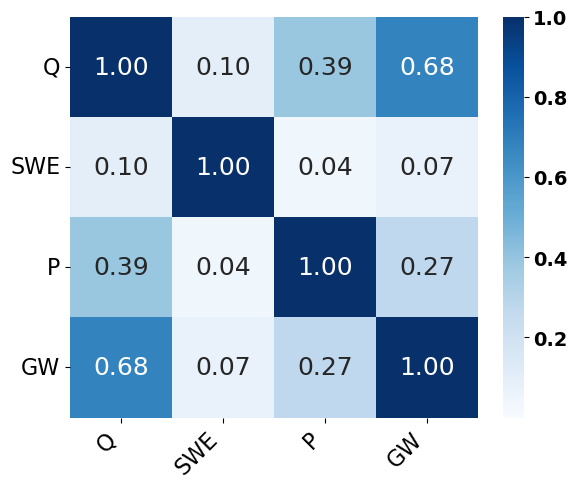

In [37]:
FIG_SIZE = (6, 5)        # Compact figure size
ANNOT_FONT_SIZE = 18     # Large text inside boxes
AXIS_FONT_SIZE = 16      # Large axis labels
CBAR_TICK_SIZE = 14      # Large colorbar ticks

data_matrix_full_year = np.array([
    [1.0, 0.1017, 0.388, 0.6819],
    [0.1017, 1.0, 0.041, 0.0711],
    [0.388, 0.041, 1.0, 0.2703],
    [0.6819, 0.0711, 0.2703, 1.0]
])
labels = ['Q', 'SWE', 'P', 'GW']

fig, ax = plt.subplots(figsize=FIG_SIZE)

sns.heatmap(
    data_matrix_full_year,
    annot=True,
    fmt=".2f",                 
    cmap='Blues',
    vmin=0, vmax=1,
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={'ticks': [0.2, 0.4, 0.6, 0.8, 1.0]},
    annot_kws={"size": ANNOT_FONT_SIZE},
    ax=ax
)

ax.set_xticklabels(labels, fontsize=AXIS_FONT_SIZE, rotation=45, ha='right')
ax.set_yticklabels(labels, fontsize=AXIS_FONT_SIZE, rotation=0)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=CBAR_TICK_SIZE)
for l in cbar.ax.yaxis.get_ticklabels():
    l.set_weight("bold")

plt.tight_layout()
plt.show()

## Simulating Events

### Whole year

Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making i

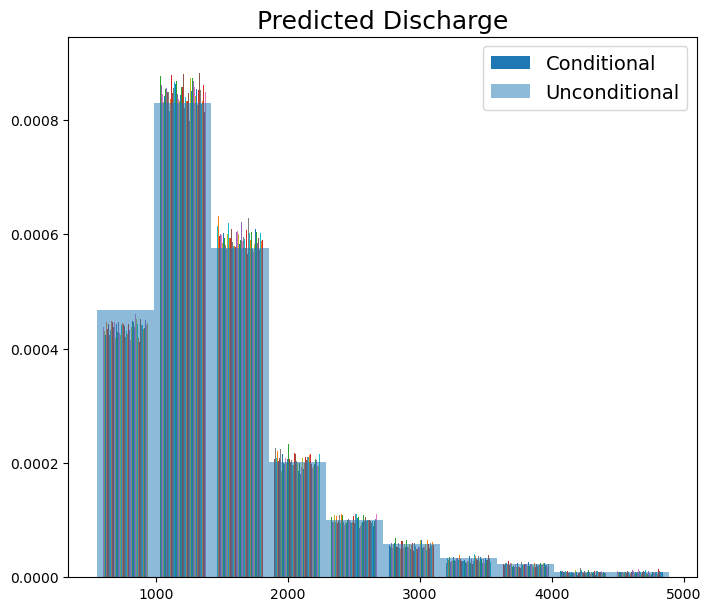

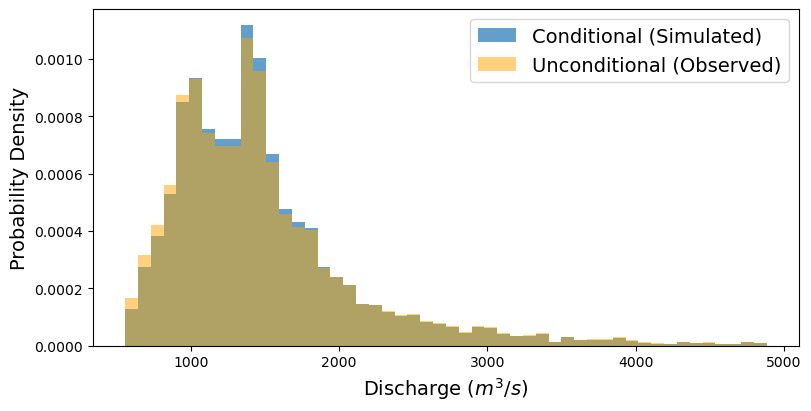

In [38]:
condition_nodes = [1, 2, 3]
condition_values = data.iloc[:,1:4].to_numpy()

Q_pred = inference(Nodes = condition_nodes,
              Values = condition_values,
              R = R_BN_1_seasonality_full_year,
              DATA = data,
              empirical_data = True,
              SampleSize = 1000,
              Output = 'full').squeeze()

fig, axes = plt.subplots(1,1, figsize=(7,6), layout='constrained')
axes.hist(Q_pred, density = True, label = 'Conditional')
axes.hist(data.iloc[:,0], density = True, label = 'Unconditional', alpha = 0.5)
axes.set_title('Predicted Discharge',fontsize=18)
axes.legend(fontsize=14)

fig, axes = plt.subplots(1, 1, figsize=(8,4), layout='constrained')

# CORRECTED: .flatten() combines all samples into one distribution
axes.hist(Q_pred.flatten(), bins=50, density=True, label='Conditional (Simulated)', alpha=0.7)
axes.hist(data.iloc[:, 0], bins=50, density=True, label='Unconditional (Observed)', alpha=0.5, color='orange')

# axes.set_title('Comparison of Marginal Distributions (Full Year)', fontsize=18)
axes.set_xlabel('Discharge ($m^3/s$)', fontsize=14)
axes.set_ylabel('Probability Density', fontsize=14)
axes.legend(fontsize=14)
plt.show()

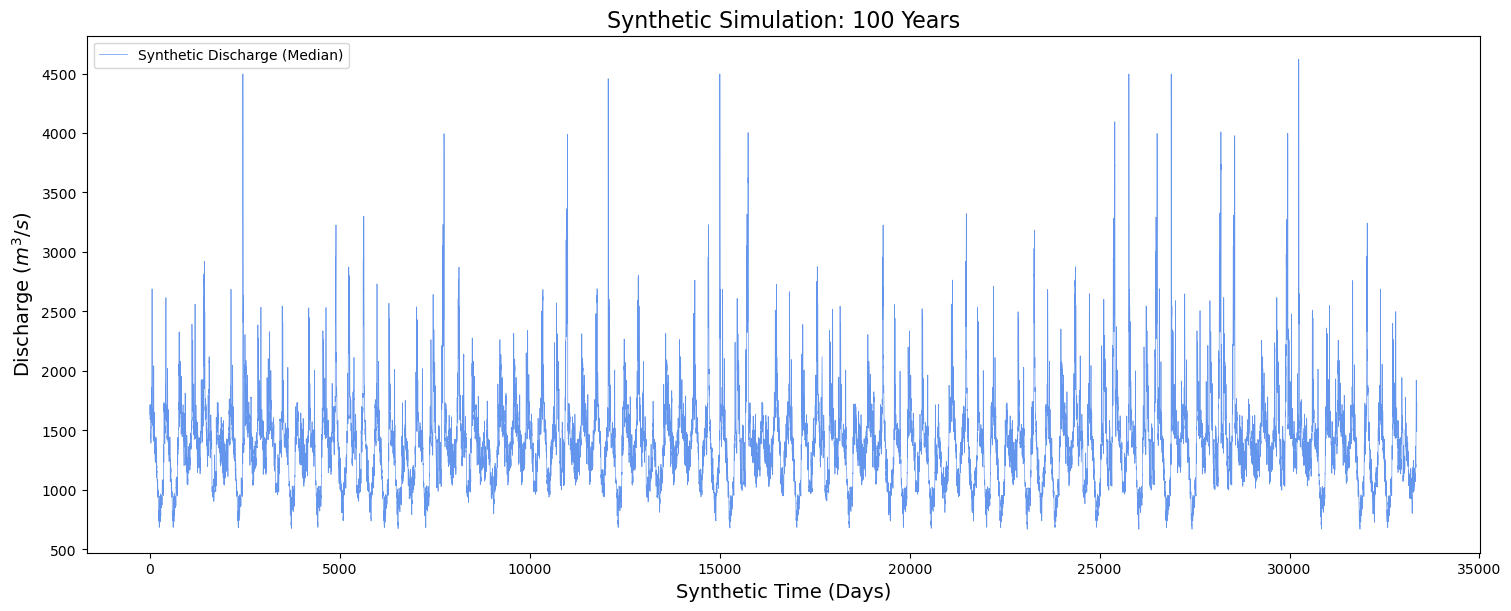

In [45]:
years = data.index.year.unique() 
n_years_sim = 100 

# Randomly select years with replacement
random_years = np.random.choice(years, size=n_years_sim, replace=True)

# Stitch the data together to create a long synthetic input series
synthetic_inputs = []
for yr in random_years:
    # Get all days for that specific year to preserve seasonality/memory
    yearly_data = data[data.index.year == yr].copy()
    synthetic_inputs.append(yearly_data)

synthetic_data = pd.concat(synthetic_inputs)

# Reset index so it's a clean 0 to N list for the loop
synthetic_data = synthetic_data.reset_index(drop=True)

init = 0
end = len(synthetic_data.index)

preds_list = []
for i in range(init, end):
    # Get values for this specific row (Snowmelt, Precipitation and Groundwater level)
    vals = synthetic_data.iloc[i, [1, 2, 3]].values.tolist()
    
    # Run inference
    res = inference(Nodes = [1, 2, 3],
                    Values = vals,
                    R = R_BN_1_seasonality_full_year,
                    DATA = data,
                    empirical_data = True,
                    SampleSize = 1000,
                    Output = 'full').squeeze()
    preds_list.append(res)

Q_pred_matrix = np.array(preds_list) 

Q_median = np.quantile(Q_pred_matrix, 0.50, axis=1)

fig, ax = plt.subplots(figsize=(15, 6), layout='constrained')

ax.plot(Q_median, color='cornflowerblue', linewidth=0.5, label='Synthetic Discharge (Median)')

ax.set_xlabel('Synthetic Time (Days)', fontsize=14)
ax.set_ylabel('Discharge ($m^3/s$)', fontsize=14)
ax.set_title(f'Synthetic Simulation: {n_years_sim} Years', fontsize=16)
ax.legend()
plt.show()

In [46]:
# date_range = pd.date_range(start='2014-01-01', periods=(end - init), freq='D')

# # 2. Calculate the Quantiles from your prediction matrix
# q05 = np.quantile(Q_pred_matrix, 0.05, axis=1)
# q50 = np.quantile(Q_pred_matrix, 0.50, axis=1) # Median prediction
# q95 = np.quantile(Q_pred_matrix, 0.95, axis=1)

# # 3. Get the actual Observations (Discharge is at index 0)
# observations = data.iloc[init:end, 0].values

# # 4. Calculate Residual Error (Observation - Median Prediction)
# residuals = observations - q50

# # 5. Create the DataFrame
# df_sim = pd.DataFrame({
#     'date': date_range,
#     '5% confidence interval': q05,
#     '50% confidence interval': q50,
#     '95% confidence interval': q95,
#     'residual error': residuals
# })

# # 6. Save to CSV
# # index=False ensures the row numbers aren't saved as a separate column
# df_sim.to_csv('discharge_sim.csv', index=False)

# print("File 'discharge_sim.csv' saved successfully.")
# print(df_sim.head()) # Show first few rows to verify

df_sim = pd.DataFrame({
    'index': range(len(Q_median)), 
    '50% confidence interval': Q_median
})

# 4. Save to CSV
# This creates a lightweight file with just 2 columns instead of 1000
df_sim.to_csv('discharge_sim.csv', index=False)

print("File 'discharge_sim.csv' saved successfully.")
print(df_sim.head())

File 'discharge_sim.csv' saved successfully.
   index  50% confidence interval
0      0              1590.899798
1      1              1712.900966
2      2              1631.127012
3      3              1631.695537
4      4              1676.964515


### Spring season

Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  1%
Making inference. Progress:  1%
Making inference. Progress:  1%
Making inference. Progress:  1%
Making inference. Progress:  1%
Making inference. Progress:  1%
Making inference. Progress:  1%
Making inference. Progress:  1%
Making inference. Progress:  1%
Making inference. Progress:  1%
Making inference. Progress:  1%
Making inference. Progress:  1%
Making inference. Progress:  1%
Making inference. Progress:  1%
Making i

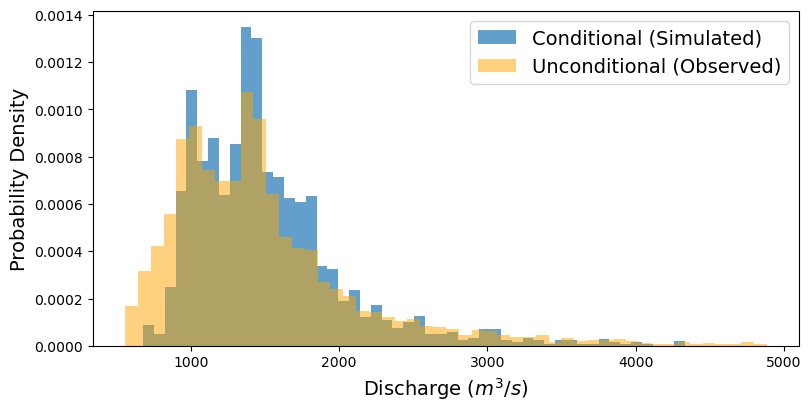

In [41]:
condition_nodes = [1, 2, 3]
condition_values = data_spring.iloc[:,1:4].to_numpy()

Q_pred = inference(Nodes = condition_nodes,
              Values = condition_values,
              R = R_BN_1_seasonality_spring,
              DATA = data_spring,
              empirical_data = True,
              SampleSize = 1000,
              Output = 'full').squeeze()

fig, axes = plt.subplots(1, 1, figsize=(8,4), layout='constrained')

axes.hist(Q_pred.flatten(), bins=50, density=True, label='Conditional (Simulated)', alpha=0.7)
axes.hist(data.iloc[:, 0], bins=50, density=True, label='Unconditional (Observed)', alpha=0.5, color='orange')

# axes.set_title('Comparison of Marginal Distributions (Spring Season Subset)', fontsize=18)
axes.set_xlabel('Discharge ($m^3/s$)', fontsize=14)
axes.set_ylabel('Probability Density', fontsize=14)
axes.legend(fontsize=14)
plt.show()

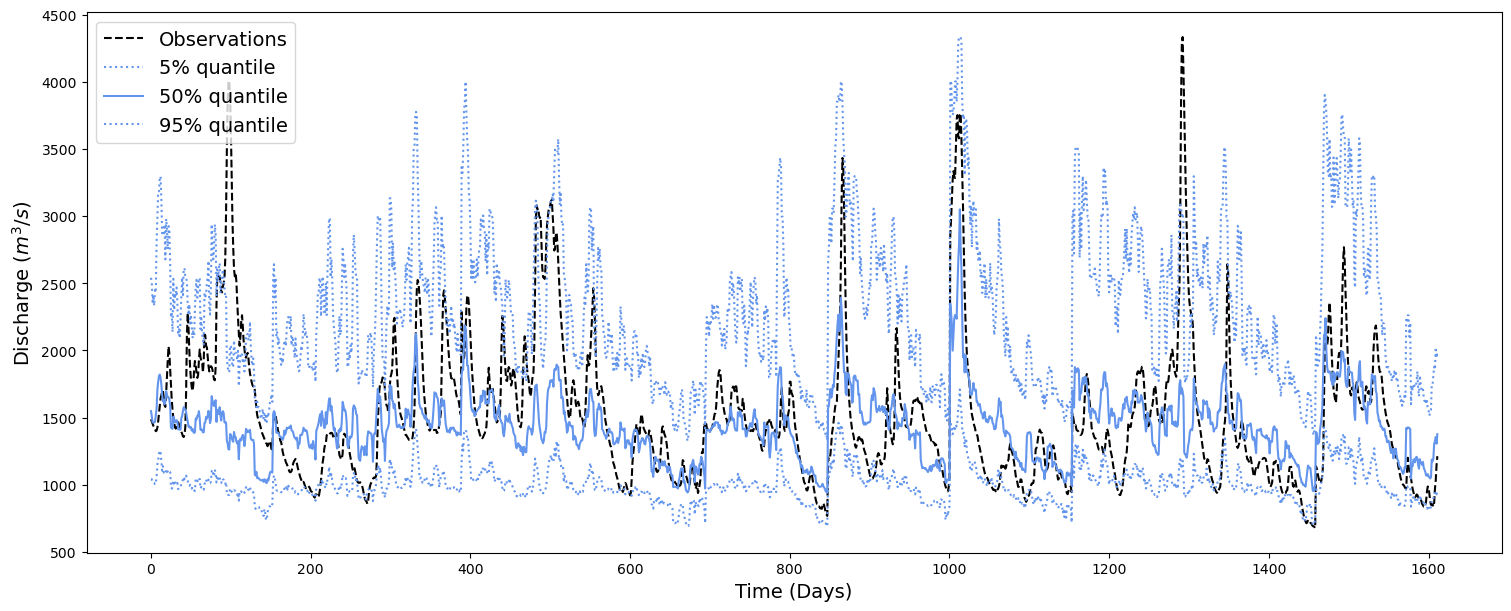

In [42]:
init = 0
end = len(data_spring.index)

preds_list = []
for i in range(init, end):
    # Get values for this specific row (Snowmelt, Precipitation and Groundwater level)
    vals = data_spring.iloc[i, [1, 2, 3]].values.tolist()
    
    # Run inference
    res = inference(Nodes = [1, 2, 3],
                    Values = vals,
                    R = R_BN_1_seasonality_spring,
                    DATA = data_spring,
                    empirical_data = True,
                    SampleSize = 1000,
                    Output = 'full').squeeze()
    preds_list.append(res)

# Convert to 2D matrix for the plot (50 rows, 1000 samples)
Q_pred_matrix = np.array(preds_list) 

# Plotting the results (Your Original Code, just swapped the variable name)
fig, axes = plt.subplots(1,1, figsize=(15,6), layout='constrained')

axes.plot(range(end-init), data_spring.iloc[init:end,0], '--k', label = 'Observations')

axes.plot(np.quantile(Q_pred_matrix, 0.05, axis=1), ':', color = 'cornflowerblue', label = '5% quantile')
axes.plot(np.quantile(Q_pred_matrix, 0.5, axis=1), color = 'cornflowerblue', label = '50% quantile')
axes.plot(np.quantile(Q_pred_matrix, 0.95, axis=1), ':', color = 'cornflowerblue', label = '95% quantile')

# axes.set_title('Waal Discharge (Spring Season)',fontsize=18)
axes.set_xlabel('Time (Days)', fontsize=14)
axes.set_ylabel('Discharge ($m^3/s$)', fontsize=14)
axes.legend(fontsize=14)
plt.show()